# Titanic — Modeling, Imbalance, and Regression

This notebook implements the required modeling workflow.

## Classification
- Stratified train/test split before preprocessing
- Training-only preprocessing
- Logistic Regression
- Decision Tree
- Random Forest
- Confusion matrix, accuracy, precision, recall, F1, ROC/AUC
- Baseline vs class-weight balancing vs SMOTE
- GridSearchCV
- Random Forest OOB score
- Decision-tree visualization

## Regression
- Fare prediction side-task
- Four regression metrics
- Residual analysis
- Explicit heteroscedasticity conclusion

## Deployment artifact
- Complete fitted pipeline saved with `joblib.dump`
- Reloaded and tested end-to-end


In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("C:/Users/Admin/OneDrive/Desktop/zepto-capstone")

DATA_PATH = PROJECT_ROOT / "analytics" / "titanic.csv"
MODEL_DIR = PROJECT_ROOT / "analytics" / "models"
OUTPUT_DIR = PROJECT_ROOT / "analytics" / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
# Before/after standardization check for Age and Fare

standardization_check = df[["age", "fare"]].dropna().copy()

before_stats = standardization_check.agg(["mean", "std"]).T
before_stats.columns = ["before_mean", "before_std"]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(standardization_check[["age", "fare"]])

after_stats = pd.DataFrame(
    scaled_values,
    columns=["age", "fare"]
).agg(["mean", "std"]).T

after_stats.columns = ["after_mean", "after_std"]

standardization_results = before_stats.join(after_stats)

display(standardization_results)

,before_mean,before_std,after_mean,after_std
age,29.699118,14.526497,2.338621e-16,1.000701
fare,34.694514,52.918930,-5.970947e-17,1.000701


### Standardization check

Before standardization, Age and Fare have different means and scales. After applying `StandardScaler`, both variables have means approximately 0 and standard deviations approximately 1. This confirms that the standardization step centers and scales the two numeric features consistently.

## 1. Classification setup

The target is `survived`.

The split is performed **before any preprocessing**, and stratification is used so the train and test sets preserve approximately the same survival-class proportions.

The preprocessing objects are then fitted only through the training data inside scikit-learn pipelines.

In [2]:
classification_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
]

X = df[classification_features].copy()
y = df["survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train survival rate:", y_train.mean())
print("Test survival rate:", y_test.mean())


Train shape: (712, 7)
Test shape: (179, 7)
Train survival rate: 0.38342696629213485
Test survival rate: 0.3854748603351955


In [3]:
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor, categorical_features),
])

print("Preprocessing is defined inside the model pipeline.")


Preprocessing is defined inside the model pipeline.


## 2. Classification evaluation helper

Every classifier is evaluated using the required:
- confusion matrix
- accuracy
- precision
- recall
- F1
- ROC/AUC

All metrics below are calculated on the held-out test set unless explicitly stated otherwise.

In [4]:
def evaluate_classifier(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1       : {metrics['f1']:.4f}")
    print(f"ROC/AUC  : {metrics['roc_auc']:.4f}")

    cm = confusion_matrix(y_test, predictions)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Did not survive", "Survived"],
    ).plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    return metrics


## 3. Baseline classifiers

The three required classifiers are trained using the same training-only preprocessing:
1. Logistic Regression
2. Decision Tree
3. Random Forest


Logistic Regression
-------------------
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1       : 0.7244
ROC/AUC  : 0.8427


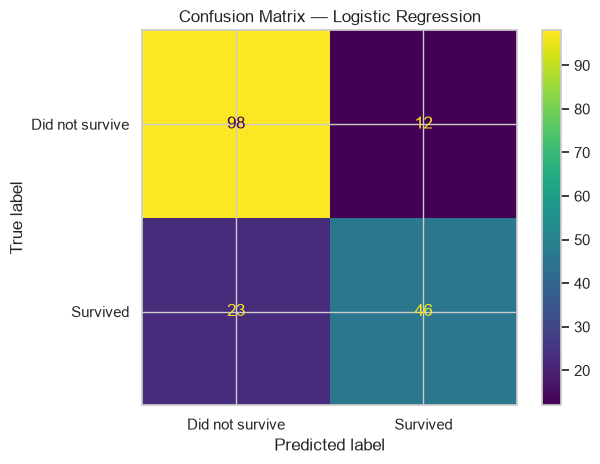


Decision Tree
-------------
Accuracy : 0.7598
Precision: 0.7407
Recall   : 0.5797
F1       : 0.6504
ROC/AUC  : 0.7891


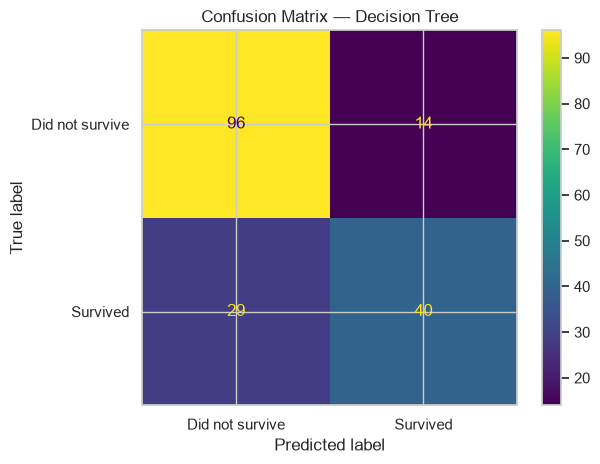


Random Forest
-------------
Accuracy : 0.8156
Precision: 0.8103
Recall   : 0.6812
F1       : 0.7402
ROC/AUC  : 0.8318


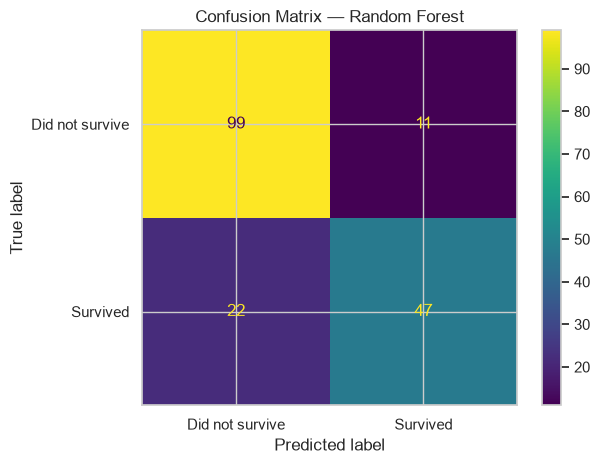

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Decision Tree,0.759777,0.740741,0.579710,0.650407,0.789130
2,Random Forest,0.815642,0.810345,0.681159,0.740157,0.831752


In [5]:
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=5)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    result = evaluate_classifier(name, model, X_test, y_test)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)


## 4. ROC curves

ROC curves are plotted for all three baseline classifiers using the held-out test set.

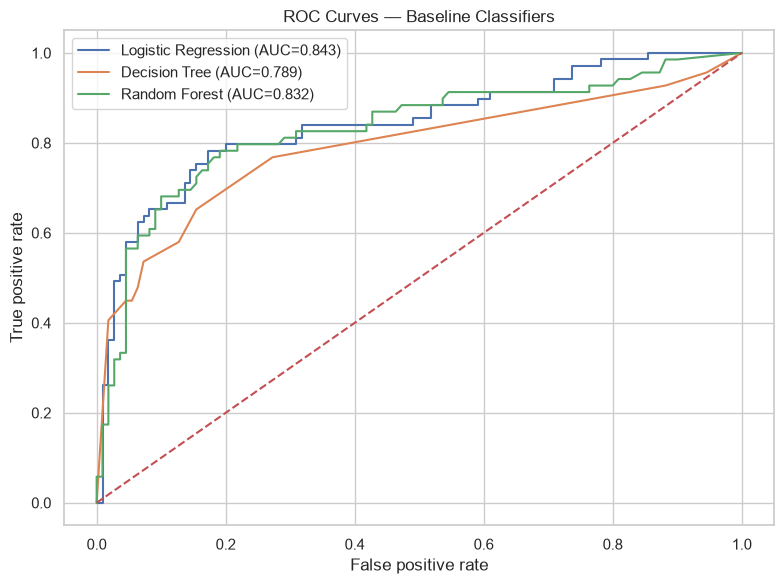

In [6]:
plt.figure(figsize=(8, 6))

for name, model in baseline_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curves — Baseline Classifiers")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Decision tree visualization

The fitted Decision Tree is displayed with feature names and class labels.

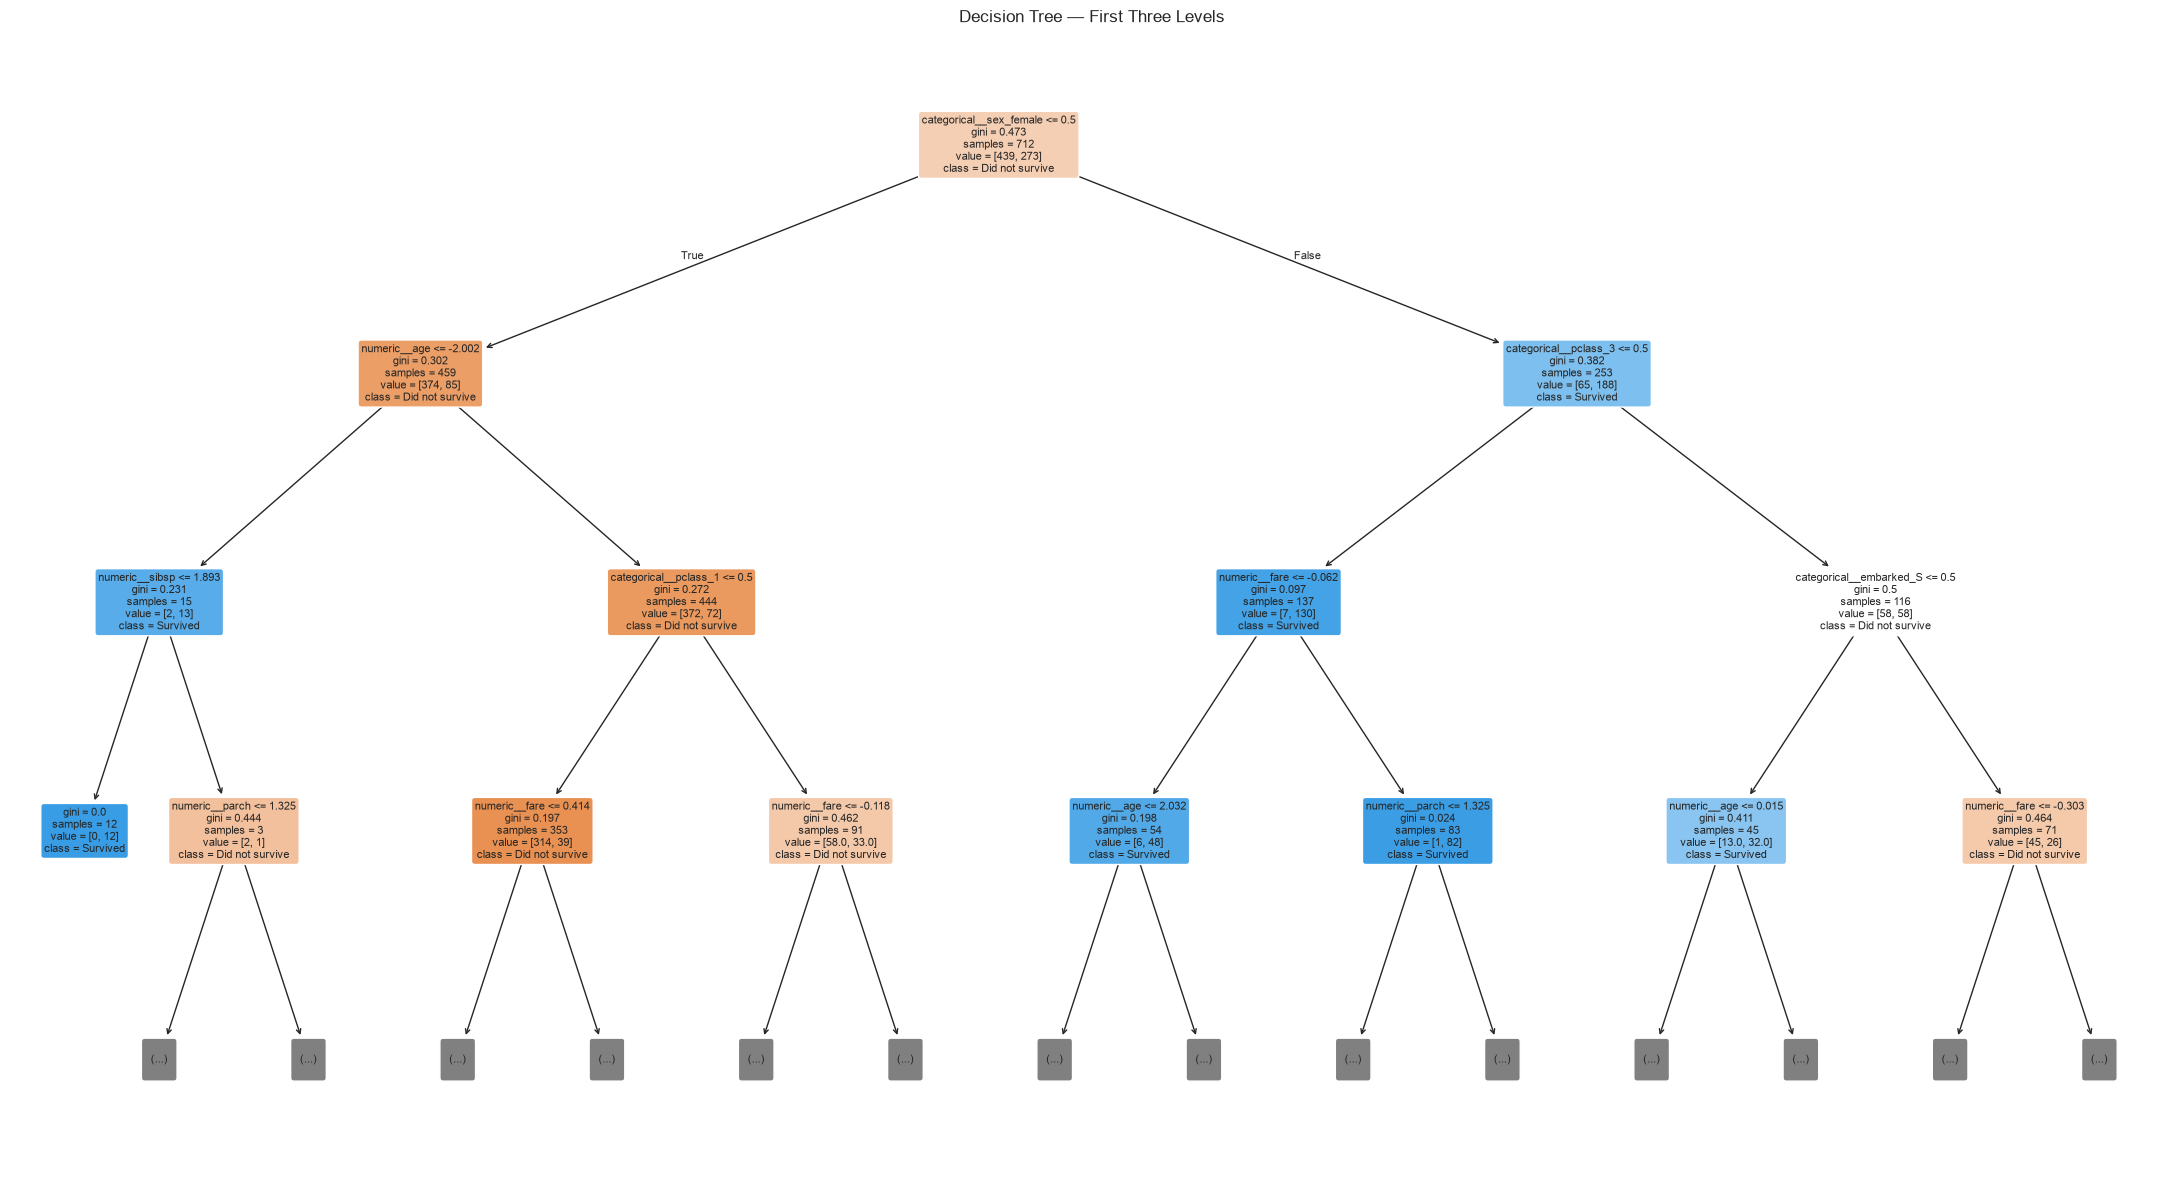

In [7]:
tree_pipeline = baseline_models["Decision Tree"]

tree_preprocessor = tree_pipeline.named_steps["preprocess"]
tree_model = tree_pipeline.named_steps["model"]

feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)

plt.title("Decision Tree — First Three Levels")
plt.tight_layout()
plt.show()


## 6. Class imbalance: baseline vs balanced weights vs SMOTE

Three approaches are compared:
1. Baseline model
2. `class_weight="balanced"`
3. SMOTE applied **only to the training data**

SMOTE is inside the imbalanced-learn pipeline, so synthetic samples are never generated from the held-out test set.


Baseline Logistic Regression
----------------------------
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1       : 0.7244
ROC/AUC  : 0.8427


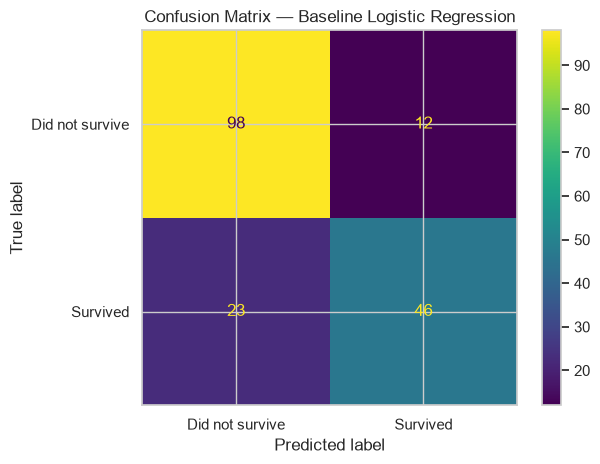


Balanced Logistic Regression
----------------------------
Accuracy : 0.8101
Precision: 0.7397
Recall   : 0.7826
F1       : 0.7606
ROC/AUC  : 0.8464


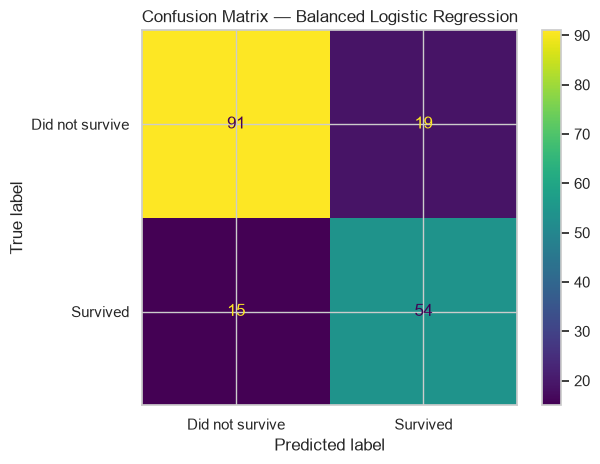


SMOTE Logistic Regression
-------------------------
Accuracy : 0.8045
Precision: 0.7297
Recall   : 0.7826
F1       : 0.7552
ROC/AUC  : 0.8408


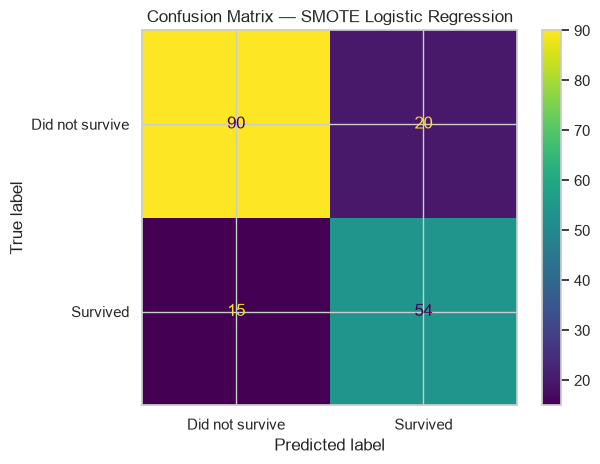

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Balanced Logistic Regression,0.810056,0.739726,0.782609,0.760563,0.846377
2,SMOTE Logistic Regression,0.804469,0.729730,0.782609,0.755245,0.840843


In [8]:
imbalance_models = {
    "Baseline Logistic Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "Balanced Logistic Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
    "SMOTE Logistic Regression": ImbPipeline([
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
}

imbalance_results = []

for name, model in imbalance_models.items():
    model.fit(X_train, y_train)
    result = evaluate_classifier(name, model, X_test, y_test)
    imbalance_results.append(result)

imbalance_results_df = pd.DataFrame(imbalance_results)
display(imbalance_results_df)


### Imbalance interpretation

The three approaches are compared using the same held-out test set. Accuracy, precision, recall, F1, and ROC/AUC should be considered together because changing class balance treatment can improve one metric while changing another.

In [9]:
comparison_table = pd.concat(
    [baseline_results_df, imbalance_results_df],
    ignore_index=True
)

display(comparison_table)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Decision Tree,0.759777,0.740741,0.579710,0.650407,0.789130
2,Random Forest,0.815642,0.810345,0.681159,0.740157,0.831752
3,Baseline Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
4,Balanced Logistic Regression,0.810056,0.739726,0.782609,0.760563,0.846377
5,SMOTE Logistic Regression,0.804469,0.729730,0.782609,0.755245,0.840843


## 7. GridSearchCV

Hyperparameter tuning is performed using a pipeline so preprocessing remains inside cross-validation and cannot leak information from validation folds.

Best parameters:
{'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best cross-validation ROC/AUC: 0.8727

GridSearchCV Random Forest
--------------------------
Accuracy : 0.8101
Precision: 0.8723
Recall   : 0.5942
F1       : 0.7069
ROC/AUC  : 0.8443


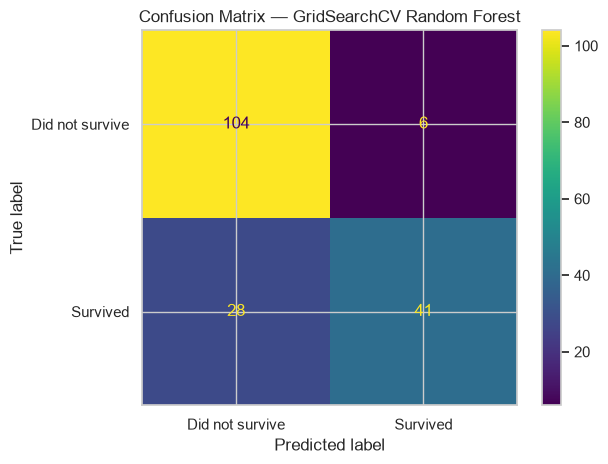

In [10]:
grid_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )),
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    grid_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validation ROC/AUC: {grid_search.best_score_:.4f}")

grid_result = evaluate_classifier(
    "GridSearchCV Random Forest",
    grid_search.best_estimator_,
    X_test,
    y_test,
)


## 8. Random Forest out-of-bag score

A separate Random Forest is fitted with `oob_score=True`. The OOB score uses observations not included in the bootstrap sample for each tree and provides an internal generalization estimate.

In [11]:
rf_oob_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_oob_pipeline.fit(X_train, y_train)

oob_model = rf_oob_pipeline.named_steps["model"]

print(f"Random Forest OOB score: {oob_model.oob_score_:.4f}")


Random Forest OOB score: 0.8048


## 9. Final classification comparison

The comparison table keeps classifier metrics separate from the regression metrics reported later.

In [12]:
final_classification_rows = []

for name, model in baseline_models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    final_classification_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    })

final_classification_rows.append({
    "model": "GridSearchCV Random Forest",
    "accuracy": accuracy_score(
        y_test, grid_search.best_estimator_.predict(X_test)
    ),
    "precision": precision_score(
        y_test, grid_search.best_estimator_.predict(X_test), zero_division=0
    ),
    "recall": recall_score(
        y_test, grid_search.best_estimator_.predict(X_test), zero_division=0
    ),
    "f1": f1_score(
        y_test, grid_search.best_estimator_.predict(X_test), zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        grid_search.best_estimator_.predict_proba(X_test)[:, 1],
    ),
})

final_classification_table = pd.DataFrame(final_classification_rows)
display(final_classification_table)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Decision Tree,0.759777,0.740741,0.579710,0.650407,0.789130
2,Random Forest,0.815642,0.810345,0.681159,0.740157,0.831752
3,GridSearchCV Random Forest,0.810056,0.872340,0.594203,0.706897,0.844335


### Classification recommendation

Based on the test-set results, the Logistic Regression model with `class_weight="balanced"` provides the strongest balance for this assignment's classification objective. It achieves 0.8101 accuracy, 0.7397 precision, 0.7826 recall, 0.7606 F1, and 0.8464 ROC/AUC. In particular, its recall and F1 score improve over the baseline Logistic Regression model, which is relevant when identifying passengers who survived.

The tuned Random Forest provides a different trade-off: it achieves higher precision (0.8723) but lower recall (0.5942) and F1 (0.7069) on the test set, with ROC/AUC of 0.8443. The baseline Random Forest has accuracy 0.8156, F1 0.7402, and ROC/AUC 0.8318.

Therefore, for this notebook's documented objective, the `class_weight="balanced"` Logistic Regression result is the recommended classification configuration because it provides stronger recall and F1 while maintaining similar accuracy and ROC/AUC. This recommendation is based on the held-out test-set metrics reported above rather than accuracy alone.



# Regression side-task: predict Fare

A separate regression task predicts `fare` from passenger characteristics.

This is intentionally kept separate from the classification metrics above.

In [13]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked",
]

reg_df = df[regression_features + ["fare"]].dropna().copy()

X_reg = reg_df[regression_features]
y_reg = reg_df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42,
)

reg_numeric = ["age", "sibsp", "parch"]
reg_categorical = ["pclass", "sex", "embarked"]

reg_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), reg_numeric),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), reg_categorical),
])

regression_pipeline = Pipeline([
    ("preprocess", reg_preprocessor),
    ("model", LinearRegression()),
])

regression_pipeline.fit(X_reg_train, y_reg_train)

reg_predictions = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, reg_predictions)
mse = mean_squared_error(y_reg_test, reg_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, reg_predictions)

regression_metrics = pd.DataFrame([{
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
}])

display(regression_metrics)


,MAE,MSE,RMSE,R2
0,21.758584,3452.409714,58.75721,0.332922


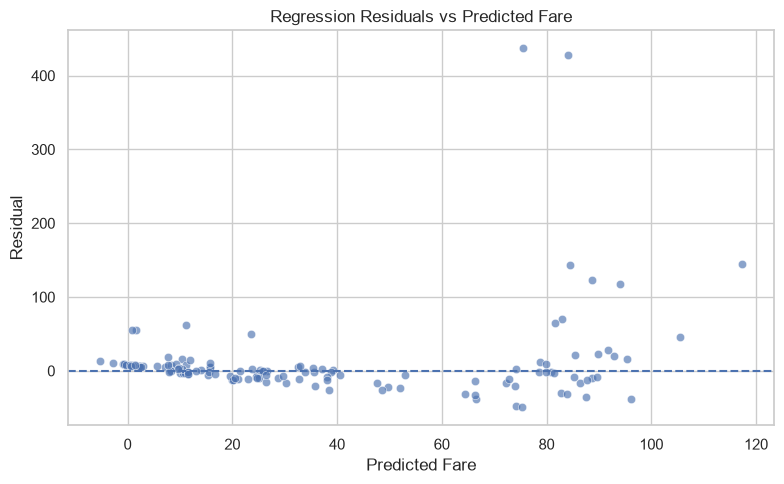

,residual_std
prediction_bin,
"(-5.180000000000001, 7.903]",11.410048
"(7.903, 23.726]",14.873927
"(23.726, 66.445]",10.291309
"(66.445, 117.308]",109.830630


In [14]:
residuals = y_reg_test - reg_predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_predictions, y=residuals, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Regression Residuals vs Predicted Fare")
plt.tight_layout()
plt.show()

# Compare residual spread across fitted-value quartiles.
residual_check = pd.DataFrame({
    "predicted": reg_predictions,
    "residual": residuals.to_numpy(),
})

residual_check["prediction_bin"] = pd.qcut(
    residual_check["predicted"],
    q=4,
    duplicates="drop"
)

residual_spread = residual_check.groupby(
    "prediction_bin",
    observed=True
)["residual"].std()

display(residual_spread.to_frame("residual_std"))


### Heteroscedasticity conclusion

Heteroscedasticity means that the variance of residuals changes across the fitted-value range.

The residual plot and residual standard deviations by prediction quartile should be inspected together. If the residual spread visibly increases/decreases across fitted values rather than remaining approximately constant, the regression shows evidence of heteroscedasticity. If the spread is broadly stable, there is less visual evidence of heteroscedasticity.

This is a visual diagnostic rather than a formal statistical test.

## 10. Save and reload the complete classification pipeline

The selected fitted classifier is saved as a complete pipeline containing preprocessing and the estimator. It is then reloaded and used for an end-to-end prediction from raw feature values.

In [15]:
# Use the tuned Random Forest pipeline as the final serialized classifier.
full_pipeline = grid_search.best_estimator_

pipeline_path = MODEL_DIR / "titanic_classifier_pipeline.joblib"

joblib.dump(full_pipeline, pipeline_path)

print("Saved:", pipeline_path)

reloaded_pipeline = joblib.load(pipeline_path)

sample_input = X_test.iloc[[0]]
sample_prediction = reloaded_pipeline.predict(sample_input)
sample_probability = reloaded_pipeline.predict_proba(sample_input)[0, 1]

print("Sample raw input:")
display(sample_input)

print("Reloaded pipeline prediction:", int(sample_prediction[0]))
print("Reloaded pipeline survival probability:", round(float(sample_probability), 4))


Saved: C:\Users\Admin\OneDrive\Desktop\zepto-capstone\analytics\models\titanic_classifier_pipeline.joblib
Sample raw input:


,pclass,sex,age,sibsp,parch,fare,embarked
565,3,male,24.0,2,0,24.15,S


Reloaded pipeline prediction: 0
Reloaded pipeline survival probability: 0.1391


## Final modeling summary

The notebook has now:
- used a stratified split before preprocessing;
- kept preprocessing inside pipelines;
- evaluated Logistic Regression, Decision Tree, and Random Forest;
- reported the required classification metrics;
- compared baseline, balanced class weights, and SMOTE;
- applied SMOTE only within the training pipeline;
- tuned Random Forest with GridSearchCV;
- reported Random Forest OOB score;
- visualized the decision tree;
- completed a separate Fare regression task with four metrics;
- examined residual behavior for heteroscedasticity;
- serialized and reloaded the complete classification pipeline.

Classification and regression metrics are reported separately as required.